In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from ast import literal_eval

from skimage import io
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

In [33]:
# --- CONFIG ---

THRESHOLD = None           # e.g. 0.3 to plot only |r|>=0.3; None to skip thresholding

# --- Significance filtering ---
USE_SIGNIFICANCE = True    # if True, filter by significance (see P_VALUE_COLUMN)
P_VALUE_COLUMN = "p_fdr"   # "p_fdr" (recommended) or "p_value"
SIGNIFICANCE_ALPHA = 0.05  # p-value cutoff


POS_PATH = Path('/Volumes/LaCie/larval_HuC/imaging/7dpf_positive_correlations_25s_no_HCl_1000_corrected.csv')
NEG_PATH = Path('/Volumes/LaCie/larval_HuC/imaging/7dpf_negative_correlations_25s_no_HCl_1000_corrected.csv')

REF_BRAIN_PATH = Path("/Volumes/LaCie/area_masks/T_AVG_HuC.tif")

In [34]:
def scatter_plots(axs, ref_brain, coords, regressor_corr, valence, vmin=None, vmax=None):
    dimensions = [(0, 'upper'), (2, 'lower')]  # Horizontal, Sagittal
    coord_indices = [(2, 1), (1, 0)]  # Horizontal (Z vs Y), Sagittal (Y vs X)

    scatter_list = []

    # Custom colormaps
    cmap_neg = LinearSegmentedColormap.from_list('neg_cmap', ['pink', 'magenta'])
    cmap_pos = LinearSegmentedColormap.from_list('pos_cmap', ['lightgreen', 'darkgreen'])

    for i, (ax, (dim, origin), (x_idx, y_idx)) in enumerate(zip(axs, dimensions, coord_indices)):
        proj = np.nanmean(ref_brain, axis=dim)

        # 🔁 Rotate horizontal view + adjust coordinates
        if dim == 0:
            proj = np.rot90(proj, k=1)
            ax.imshow(proj, cmap='gray_r', alpha=0.3, origin='lower')

            # Rotate coordinates: new_x = Y, new_y = height - Z
            rotated_x = coords[:, y_idx]              # Y
            rotated_y = proj.shape[0] - coords[:, x_idx]  # flip Z

            for val in [0, 1]:
                cmap = cmap_pos if val == 1 else cmap_neg
                scatter = ax.scatter(
                    rotated_x[valence == val],
                    rotated_y[valence == val],
                    c=regressor_corr[valence == val],
                    cmap=cmap,
                    s=10, edgecolor='none', alpha=0.9,
                    vmin=vmin, vmax=vmax
                )
                scatter_list.append(scatter)

        else:
            ax.imshow(proj, cmap='gray_r', alpha=0.3, origin=origin)
            for val in [0, 1]:
                cmap = cmap_pos if val == 1 else cmap_neg
                scatter = ax.scatter(
                    coords[valence == val][:, x_idx],
                    coords[valence == val][:, y_idx],
                    c=regressor_corr[valence == val],
                    cmap=cmap,
                    s=10, edgecolor='none', alpha=0.9,
                    vmin=vmin, vmax=vmax
                )
                scatter_list.append(scatter)

        ax.axis('off')
        ax.set_aspect('equal')

    return scatter_list


def plot_valence_corr(ref_brain, correlation_data, vmin=None):
    fig = plt.figure(figsize=(6, 9))

    # Only 2 subplots: horizontal (top), sagittal (bottom)
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])
    gs.update(hspace=-0.6) 

    ax1 = fig.add_subplot(gs[0])   # horizontal (axis=0)
    ax2 = fig.add_subplot(gs[1])   # sagittal (axis=2)

    axs = [ax1, ax2]

    coords = np.vstack(correlation_data['coords'])
    regressor_corr = correlation_data['correlation'].values
    valence = correlation_data['valence'].values

    vmin = 0 if vmin is None else vmin 
    vmax = 0.7

    scatter_list = scatter_plots(axs, ref_brain, coords, regressor_corr, valence, vmin=vmin, vmax=vmax)

    # Colorbars positioned to right of the figure
    cbar_ax1= fig.add_axes([1.08, 0.4, 0.02, 0.3])  # Position for the first color bar
    cbar_ax2 = fig.add_axes([0.88, 0.4, 0.02, 0.3])  # Position for the second color bar

    cbar1 = fig.colorbar(scatter_list[0], cax=cbar_ax1)
    cbar1.set_label('Negative r value', fontsize=20)
    cbar1.ax.tick_params(labelsize=20)

    cbar2 = fig.colorbar(scatter_list[1], cax=cbar_ax2)
    cbar2.set_label('Positive r value', fontsize=20)
    cbar2.ax.tick_params(labelsize=20)

    plt.show()
    return fig

In [35]:
## Load and process data for plotting 
pos = pd.read_csv(POS_PATH)
neg = pd.read_csv(NEG_PATH)
ref_brain = io.imread(REF_BRAIN_PATH)


pos['valence'] = 1
neg['valence'] = 0
dataframes = [pos, neg]

valence = pd.concat(dataframes, ignore_index=True)
valence = valence[valence['area'] != 'not_assigned']

valence["coords"] = valence["coords"].apply(literal_eval) # deserialise from 


In [36]:
# --- Filter to significant points (and optional threshold on |r|) ---

plot_df = valence.copy()

if USE_SIGNIFICANCE:
    if P_VALUE_COLUMN not in plot_df.columns:
        raise ValueError(
            f"Expected a '{P_VALUE_COLUMN}' column for significance filtering. "
            f"Available columns: {list(plot_df.columns)}"
        )
    plot_df = plot_df[plot_df[P_VALUE_COLUMN] < SIGNIFICANCE_ALPHA].copy()

if THRESHOLD is not None:
    plot_df = plot_df[np.abs(plot_df["correlation"]) >= THRESHOLD].copy()



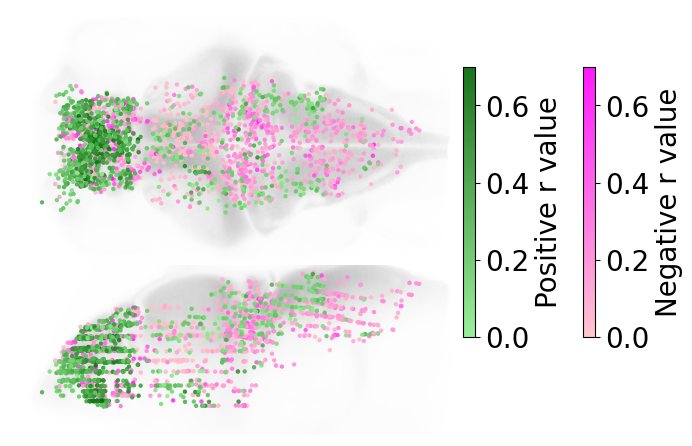

In [37]:
figure = plot_valence_corr(ref_brain, plot_df, vmin=THRESHOLD) 

## Optional BHV neurons valence plot 

In [40]:
BHV_PATH = Path("/Volumes/LaCie/larval_HuC/imaging/7dpf_bhv_vigor_correlations_1000_corrected.csv")


bhv_data = pd.read_csv(BHV_PATH)
pos_data = pd.read_csv(POS_PATH)
neg_data = pd.read_csv(NEG_PATH)

pos_data['valence'] = 1
neg_data['valence'] = 0 


## Create merged dataframe
bhv_data = bhv_data.rename(columns={
    'correlation': 'bhv_correlation',
    'p_fdr': 'bhv_pfdr'
})

pos_data = pos_data.rename(columns={
    'correlation': 'pos_correlation',
    'p_fdr': 'pos_pfdr'
})

neg_data = neg_data.rename(columns={
    'correlation': 'neg_correlation',
    'p_fdr': 'neg_pfdr'
})

merged = bhv_data.merge(
    pos_data[['fish_id', 'neuron_id', 'pos_correlation', 'pos_pfdr']],
    on=['fish_id', 'neuron_id'],
    how='left'
)

merged = merged.merge(
    neg_data[['fish_id', 'neuron_id', 'neg_correlation', 'neg_pfdr']],
    on=['fish_id', 'neuron_id'],
    how='left'
)

# Safer than eval()
merged["coords"] = merged["coords"].apply(literal_eval)

# Optional: drop unassigned
if "area" in merged.columns:
    merged = merged[merged["area"] != "not_assigned"].copy()


In [58]:
significant_neurons = merged[
    (merged['bhv_pfdr'] < 0.05) &
    ((merged['pos_pfdr'] < 0.05) | (merged['neg_pfdr'] < 0.05))
]

In [59]:
significant_neurons = significant_neurons.copy()

# Assign valence: 1 if pos_pvalue significant, 0 if neg_pvalue significant
# If both are significant, this will assign 1 (you can customize this logic if needed)
significant_neurons['valence'] = None  # Initialize the column

# Assign valence = 1 for significant positive responders
significant_neurons.loc[significant_neurons['pos_pfdr'] < 0.05, 'valence'] = 1

# Assign valence = 0 for significant negative responders (overwrites if both are sig)
significant_neurons.loc[significant_neurons['neg_pfdr'] < 0.05, 'valence'] = 0

In [60]:
# STEP 1: Create the correlation_data with correct values per valence
correlation_data = significant_neurons.copy()

# Use pos_correlation if valence = 1, neg_correlation if valence = 0
correlation_data['correlation'] = np.where(
    correlation_data['valence'] == 1,
    correlation_data['pos_correlation'],
    correlation_data['neg_correlation']
)


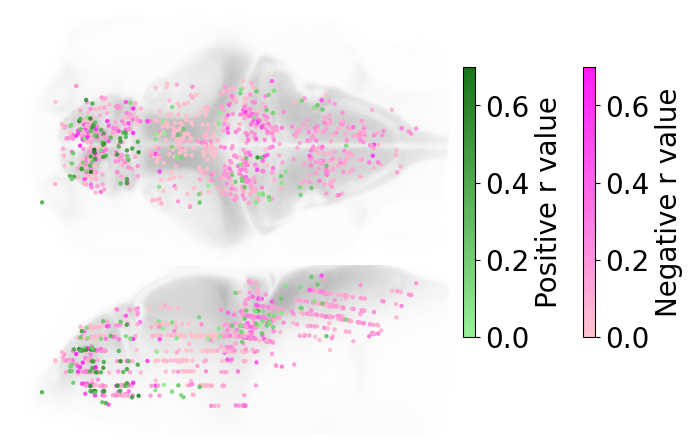

In [61]:
figure = plot_valence_corr(ref_brain, correlation_data, vmin=THRESHOLD)